# Boolean synthesis: two EPFL case studies

Follow the same functions through **equations → digital gates → XAG / AIG / k-LUT → quantum circuits**.

We use two [EPFL benchmarks](https://github.com/lsils/benchmarks): **int2float** (integer-to-floating-point conversion) and **cavlc** (variable-length coding). For readable diagrams, inspect output **3** of int2float and outputs **4, 5** of cavlc, using zero-based output indices. These are benchmark-derived output cones, not the complete benchmarks. The final section compares the complete benchmarks too.

The first cone exposes XOR structure; the second emphasizes shared AND logic. Gate diversity is measured, not assumed: an XAG is allowed to contain no XOR nodes.

## 1. Setup

Use the [setup guide](../../docs/setup.md), including system Graphviz, and build the native helper explicitly. This study shares the [Boolean workspace tutorial](../tutorials/boolean_workspace.ipynb) environment.


In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Math, SVG, HTML
from logique.synthesis import synthesize, METHODS
from logique.paths import native_executable, cache_directory
from logique.benchmarks.datasets import download_benchmarks, benchmark_manifest
from logique.benchmarks.provenance import environment
from logique.benchmarks.export import export_result
from logique.benchmarks.runner import new_run_directory
from logique.verification import validate, truth_outputs, verify_small_quantum
from logique.verification.classical import input_assignments
from logique.workspace import workspace_analysis, borrowing_demo, verify_borrowing
from logique.visualization.circuits import network_figure, circuit_window
from logique.visualization import boolean as bv
ROOT = Path(os.environ.get("LOGIQUE_WORKSPACE", Path.cwd())).resolve()
OUT = Path(os.environ["LOGIQUE_OUTPUT"]) if "LOGIQUE_OUTPUT" in os.environ else new_run_directory()
OFFLINE = os.environ.get("LOGIQUE_OFFLINE", "0") == "1"
native_executable()  # Build explicitly during setup; notebooks never compile dependencies.
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

import shutil
from io import StringIO
assert shutil.which("dot"), "Install system Graphviz."
paths = download_benchmarks(("int2float", "cavlc"), offline=OFFLINE)

selected = {"int2float": [3], "cavlc": [4, 5]}
results = {name: {method: synthesize(paths[name], method, outputs=outputs, k=4) for method in METHODS} for name, outputs in selected.items()}
for methods in results.values():
    for result in methods.values():
        validate(result)
display(pd.DataFrame([{ "benchmark": name, "original outputs": outputs, **bv.graph_stats(results[name]["xag"].metadata["network"])} for name, outputs in selected.items()]))


,benchmark,original outputs,AND,XOR,LUT,levels,used_inputs,shared_internal_nodes
0,int2float,[3],8,4,0,7,9,0
1,cavlc,"[4, 5]",19,0,0,6,8,5


## 2. Boolean functions in LaTeX

These are **exact factored definitions**, not expanded sum-of-products. Read top to bottom: each intermediate `t` is defined once. Input $x_i$ is primary input $i$ in the imported AIGER file, including unused inputs. For int2float, $y_0$ is original output 3; for cavlc, $(y_0,y_1)$ are original outputs (4,5).

$\land$ means AND, $\lor$ means OR, $\oplus$ means XOR, and a bar means NOT. De Morgan notation exposes NOR gates; it does not change the function or native graph. Signal numbers are local to each representation.

In [2]:
for name in selected:
    graph = results[name]["xag"].metadata["network"]
    display(Markdown(f"### {name}: outputs {selected[name]}"))
    for block in bv.latex_blocks(graph):
        display(Math(block))
    assignments = input_assignments(len(graph["inputs"]))
    np.testing.assert_array_equal(
        bv.evaluate_gate_rows(graph, assignments),
        truth_outputs(graph, assignments),
    )
    (OUT / f"{name}_selected.tex").write_text(
        "\n\n".join("$$" + block + "$$" for block in bv.latex_blocks(graph))
    )

### int2float: outputs [3]

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### cavlc: outputs [4, 5]

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 3. Digital logic with Schemdraw

Each [Schemdraw circuit](https://schemdraw.readthedocs.io/en/stable/elements/logic.html) is fully wired from its used primary inputs to its outputs. Gate labels match the intermediate signals in the equations. **Filled dots are connected fanouts; crossings with a gap are not connected.** Hollow gate bubbles mean inversion. Shared gates are drawn only once, with wires to every consumer. Graphviz routes the wires; Schemdraw renders the actual logic symbols and connections. Unused primary inputs are omitted from the drawing only. Scroll the vector drawings to inspect them at full size.

In [3]:
for name in selected:
    display(Markdown(f"### {name}"))
    fig = bv.schematic_figure(results[name]["xag"].metadata["network"])
    fig.savefig(OUT / f"{name}_logic.png", dpi=150, bbox_inches="tight")
    buffer = StringIO()
    fig.savefig(buffer, format="svg", bbox_inches="tight")
    svg = buffer.getvalue()
    (OUT / f"{name}_logic.svg").write_text(svg)
    display(HTML('<div style="overflow:auto;max-height:750px;border:1px solid #ddd">'
                 + SVG(svg).data + '</div>'))
    plt.close(fig)

### int2float

### cavlc

## 4. XAG, AIG, and 4-LUT networks

- **AIG:** two-input AND nodes with complemented edges; even XOR functions must be expressed using this basis.
- **XAG:** adds two-input XOR nodes. XOR-rich functions may become smaller, but the result depends on factoring.
- **k-LUT:** covers logic with lookup tables of at most $k$ inputs. Each LUT can implement an arbitrary local Boolean function; fewer nodes do not necessarily mean fewer quantum gates.

These are actual exported mockturtle networks. AIG keeps the imported AND structure; XAG applies the bridge's refactoring, and LUT mapping starts from that XAG. This comparison includes both representation and preprocessing effects, not a controlled optimizer-quality contest.

[Graphviz dot](https://graphviz.org/docs/layouts/dot/) gives layered, connected **SVG** graphs that stay sharp when zoomed. Green = AND; amber = XOR; blue = LUT. Red dashed edges with circles mean NOT. Numbered ports specify fanin order. Unused inputs are hidden only in the drawing. For LUT truth tables, port 0 is the least-significant assignment bit; the displayed bit string runs from the highest assignment to zero.

In [4]:
representations = {"XAG": "xag", "AIG": "aig_bennett", "4-LUT": "klut_bennett"}

def show_vector(dot, filename):
    dot.save(str(OUT / f"{filename}.dot"))
    svg = dot.pipe(format="svg").decode()
    (OUT / f"{filename}.svg").write_text(svg)
    # Scroll at the SVG's natural size instead of shrinking node labels.
    display(HTML('<div style="overflow:auto;max-height:650px;border:1px solid #ddd">'
                 + SVG(svg).data + '</div>'))

for name in selected:
    display(Markdown(f"### {name}"))
    display(pd.DataFrame([
        {"representation": label, **bv.graph_stats(results[name][method].metadata["network"])}
        for label, method in representations.items()
    ]))
    reference = results[name]["xag"].metadata["network"]
    assignments = input_assignments(len(reference["inputs"]))
    for label, method in representations.items():
        graph = results[name][method].metadata["network"]
        np.testing.assert_array_equal(
            truth_outputs(reference, assignments), truth_outputs(graph, assignments)
        )
        show_vector(bv.graphviz_graph(graph, f"{name}: {label}"),
                    f"{name}_{label.lower()}_selected")
        if label == "4-LUT":
            display(pd.DataFrame(bv.lut_table(graph)))

### int2float

,representation,AND,XOR,LUT,levels,used_inputs,shared_internal_nodes
0,XAG,8,4,0,7,9,0
1,AIG,13,0,0,7,9,0
2,4-LUT,0,0,3,3,9,0


,node,ports (0 first),truth (MSB first),hex
0,t_13,"x_2, x_5, x_7, x_8",0100000000000011,0x4003
1,t_14,"x_4, x_6, x_8, t_13",1000000100000000,0x8100
2,t_15,"x_3, x_9, x_10, t_14",1111111011111111,0xfeff


### cavlc

,representation,AND,XOR,LUT,levels,used_inputs,shared_internal_nodes
0,XAG,19,0,0,6,8,5
1,AIG,19,0,0,6,8,5
2,4-LUT,0,0,8,4,8,1


,node,ports (0 first),truth (MSB first),hex
0,t_13,"x_0, x_1, x_2, x_4",0000000011100000,0xe0
1,t_14,"x_0, x_1, x_2",00000001,0x1
2,t_15,"x_3, x_4, t_13, t_14",0000100100001111,0x90f
3,t_16,"x_5, x_6, x_7, t_15",0000000000001000,0x8
4,t_12,"x_0, x_1",0001,0x1
5,t_17,"x_2, x_3, x_4, t_12",0001000000000000,0x1000
6,t_18,"x_3, x_4, t_14, t_17",0000000011111101,0xfd
7,t_19,"x_5, x_6, x_7, t_18",0000000000001000,0x8


### Output selection changes the graph

The output cones are extracted **before** refactoring. Joint output sharing can change which XOR patterns the heuristic exposes. An AND-only XAG does not prove that the Boolean function has no useful XOR decomposition.

In [5]:
scope_rows = []
for name, outputs in selected.items():
    for scope in [[o] for o in outputs] + ([outputs] if len(outputs) > 1 else []):
        r = synthesize(paths[name], "xag", outputs=scope)
        scope_rows.append({"benchmark": name, "outputs": str(scope),
                           **bv.graph_stats(r.metadata["network"])})
display(pd.DataFrame(scope_rows))

,benchmark,outputs,AND,XOR,LUT,levels,used_inputs,shared_internal_nodes
0,int2float,[3],8,4,0,7,9,0
1,cavlc,[4],10,1,0,6,8,0
2,cavlc,[5],6,2,0,6,8,0
3,cavlc,"[4, 5]",19,0,0,6,8,5


## 5. Five quantum compilation methods

These labels match the existing tutorial; they are not five independent algorithms:

| Method | What it does |
|---|---|
| XAG specialized | Uses XOR-aware synthesis and temporary AND computation with phase-sensitive controlled rotations and cleanup. |
| AIG + Bennett | Computes AND nodes into workspace, retains intermediates, copies outputs, then reverses computation. |
| XAG + Bennett | The same retain-and-reverse schedule on the refactored AND/XOR graph. |
| 4-LUT + Bennett | Computes mapped LUT functions reversibly, then reverses intermediates. LUT arity bounds the local classical function, not the total qubit count. |
| Best-fit LHRS | Uses LUT-based hierarchical reversible synthesis with a best-fit mapping strategy and earlier cleanup/reuse. Its local LUT synthesis can cost more gates while using less workspace. |

**Bennett is an uncomputation schedule**, not a graph representation. Best-fit LHRS uses outer cut 16 and inner cut 4 here; it is not identical to fixed 4-LUT mapping.

Below are the **complete raw synthesis circuits**, not truncated windows. Inputs and workspace start in the documented computational/zero states; raw output wires may alias inputs. Use `result.oracle()` for the uniform contract $|x\rangle|y\rangle|0\rangle \mapsto |x\rangle|y\oplus f(x)\rangle|0\rangle$. That wrapper can add qubits and gates.

Controlled $R_x(\pm\pi)$ is not an exact Toffoli: keep its phase. Counts below are logical Qiskit operations, not hardware-decomposed costs.

In [6]:
columns = ["benchmark", "method", "qubits", "workspace", "gates", "depth",
           "exact_ccx", "controlled_rx_pi", "mcx_3plus", "gate_types", "validation"]
comparison = pd.DataFrame([
    {"benchmark": name, **r.summary()}
    for name, methods in results.items() for r in methods.values()
])
display(comparison[columns])

def show_circuit(result, filename):
    fig = result.circuit.draw("mpl", idle_wires=False, fold=-1)
    buffer = StringIO()
    fig.savefig(buffer, format="svg", bbox_inches="tight")
    plt.close(fig)
    svg = buffer.getvalue()
    (OUT / f"{filename}.svg").write_text(svg)
    display(HTML('<div style="overflow:auto;max-height:650px;border:1px solid #ddd">'
                 + SVG(svg).data + '</div>'))

for name, methods in results.items():
    for method, result in methods.items():
        display(Markdown(f"### {name}: {method}"))
        display(pd.DataFrame({
            "role": ["inputs", "outputs"],
            "raw qubit indices": [result.metadata["input_qubits"], result.metadata["output_qubits"]]
        }))
        show_circuit(result, f"{name}_{method}_circuit")
        export_result(result, OUT, f"{name}_{method}_selected")

,benchmark,method,qubits,workspace,gates,depth,exact_ccx,controlled_rx_pi,mcx_3plus,gate_types,validation
0,int2float,xag,19,7,32,27,1,14,0,"{'cx': 16, 'ccrx_o2': 6, 'ccrx': 4, 'ccrx_o0':...",exhaustive
1,int2float,aig_bennett,24,12,26,15,25,0,0,"{'ccx': 10, 'ccx_o0': 8, 'ccx_o2': 7, 'x': 1}",exhaustive
2,int2float,xag_bennett,23,11,32,20,15,0,0,"{'cx': 16, 'ccx_o2': 5, 'ccx': 4, 'ccx_o0': 4,...",exhaustive
3,int2float,klut_bennett,14,2,39,38,15,0,12,"{'ccx': 15, 'mcx': 12, 'cx': 9, 'x': 3}",exhaustive
4,int2float,best_fit,12,0,257,257,28,0,219,"{'mcx': 219, 'ccx': 28, 'cx': 8, 'x': 2}",exhaustive
5,cavlc,xag,29,17,36,16,2,34,0,"{'ccrx_o0': 14, 'ccrx_o2': 10, 'ccrx_o1': 6, '...",exhaustive
6,cavlc,aig_bennett,29,17,36,21,36,0,0,"{'ccx_o0': 14, 'ccx_o2': 10, 'ccx': 6, 'ccx_o1...",exhaustive
7,cavlc,xag_bennett,29,17,36,21,36,0,0,"{'ccx_o0': 14, 'ccx_o2': 10, 'ccx': 6, 'ccx_o1...",exhaustive
8,cavlc,klut_bennett,18,6,84,64,26,0,34,"{'mcx': 34, 'ccx': 26, 'cx': 16, 'x': 8}",exhaustive
9,cavlc,best_fit,12,0,70,68,17,0,47,"{'mcx': 47, 'ccx': 17, 'cx': 4, 'x': 2}",exhaustive


### int2float: xag

,role,raw qubit indices
0,inputs,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,outputs,[11]


### int2float: aig_bennett

,role,raw qubit indices
0,inputs,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,outputs,[23]


...

,role,raw qubit indices
0,inputs,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
1,outputs,"[22, 28]"


### cavlc: klut_bennett

,role,raw qubit indices
0,inputs,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
1,outputs,"[13, 17]"


### cavlc: best_fit

,role,raw qubit indices
0,inputs,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
1,outputs,"[11, 10]"


### Vary LUT size

Changing $k$ trades local synthesis difficulty against network size and workspace. Compare logical gates and qubits together; a large controlled gate still counts as one operation here.

In [7]:
lut_sizes = []
for name, outputs in selected.items():
    for k in (3, 4, 6):
        r = synthesize(paths[name], "klut_bennett", outputs=outputs, k=k)
        validate(r)
        lut_sizes.append({"benchmark": name, **r.summary()})
display(pd.DataFrame(lut_sizes)[["benchmark", "k", "LUT", "qubits", "workspace",
                                "gates", "depth", "mcx_3plus"]])

,benchmark,k,LUT,qubits,workspace,gates,depth,mcx_3plus
0,int2float,3,5,16,4,37,30,5
1,int2float,4,3,14,2,39,38,12
2,int2float,6,2,13,1,73,72,36
3,cavlc,3,11,21,9,81,62,16
4,cavlc,4,8,18,6,84,64,34
5,cavlc,6,4,14,2,130,127,88


## 6. Workspace behavior

Count workspace wires that are nonzero for **at least one** input at each expanded gate boundary. This is not the Hamming weight of a quantum state. The candidate table lists conditional known-value facts verified over all original inputs.

A fact such as “under $q_t=1$, $q_c=1$” is a starting point for conditional workspace, **not permission to insert arbitrary gates**. Any inserted computation must respect the protecting condition, restore borrowed wires, and preserve phases before the original circuit resumes. See the verified borrowing example in the [original notebook](../tutorials/boolean_workspace.ipynb) and [conditionally clean ancilla paper](https://arxiv.org/html/2407.17966v2). No borrowing transformation is applied here.

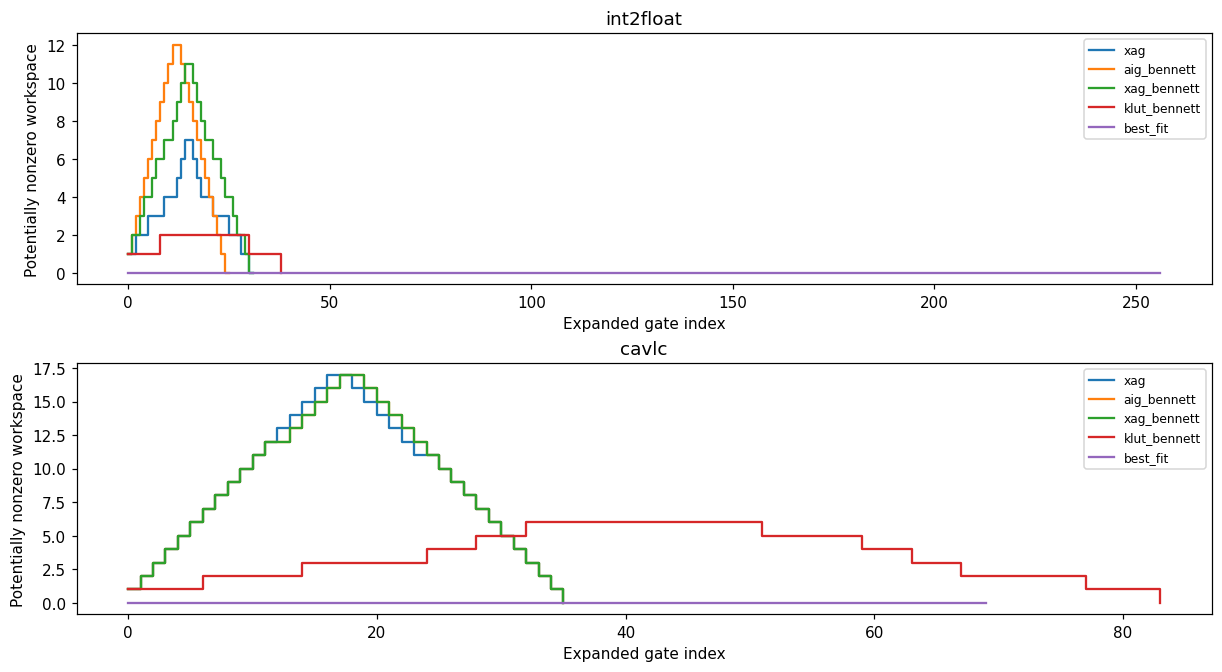

candidate facts
benchmark method                       
cavlc     aig_bennett                38
          best_fit                    6
          klut_bennett                8
          xag                        38
          xag_bennett                38
int2float aig_bennett                26
          xag                        16
          xag_bennett                16

,benchmark,method,after_gate,before_gate,condition,borrow_candidate,known_value,proof
0,int2float,xag,0,30,q12 = 1,q2,1,exhaustive reachable states
1,int2float,xag,0,1,q12 = 1,q8,1,exhaustive reachable states
2,int2float,xag,2,3,q13 = 1,q8,0,exhaustive reachable states
3,int2float,xag,2,28,q13 = 1,q12,0,exhaustive reachable states
4,int2float,xag,5,6,q14 = 1,q8,0,exhaustive reachable states
5,int2float,xag,5,25,q14 = 1,q13,1,exhaustive reachable states
6,int2float,xag,9,11,q15 = 1,q4,0,exhaustive reachable states
7,int2float,xag,9,10,q15 = 1,q8,0,exhaustive reachable states
8,int2float,xag,12,18,q16 = 1,q14,1,exhaustive reachable states
9,int2float,xag,12,18,q16 = 1,q15,1,exhaustive reachable states


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), constrained_layout=True)
facts = []
for ax, (name, methods) in zip(axes, results.items()):
    for method, result in methods.items():
        report = workspace_analysis(result, expanded=True)
        ax.step(range(len(report["occupancy"])), report["occupancy"],
                where="post", label=method)
        facts.extend({"benchmark": name, "method": method, **c}
                     for c in report["candidates"])
    ax.set(title=name, xlabel="Expanded gate index", ylabel="Potentially nonzero workspace")
    ax.legend(fontsize=8)
display(fig)
fig.savefig(OUT / "workspace.png", dpi=150)
plt.close(fig)
facts = pd.DataFrame(facts)
display(facts.groupby(["benchmark", "method"]).size().rename("candidate facts").to_frame())
display(facts.head(12))
facts.to_csv(OUT / "conditional_facts.csv", index=False)

## 7. Full-benchmark context

Now compile **every output** of both benchmarks with all five methods. These numbers are separate from the readable cones above. Export full graph SVG/DOT files, exact factored LaTeX, and raw/wrapped QPY circuits for deeper inspection; large diagrams are not squeezed into the notebook.

All functions have at most 11 inputs, so validation is exhaustive. The verifier tracks the circuit permutation **and complex phases** on every input basis state, checks native-to-Qiskit agreement, and checks wrapped oracle restoration. By linearity this covers superposed inputs for these monomial circuits with initially clean workspace; it is not a dense statevector simulation or a hardware-noise test.

In [9]:
full_results = {}
full_rows = []
for name in selected:
    full_results[name] = {}
    for method in METHODS:
        r = synthesize(paths[name], method, k=4)
        validate(r)
        full_results[name][method] = r
        full_rows.append({"benchmark": name, **r.summary()})
        export_result(r, OUT, f"{name}_{method}_full")
    graph = full_results[name]["xag"].metadata["network"]
    (OUT / f"{name}_full.tex").write_text(
        "\n\n".join("$$" + block + "$$" for block in bv.latex_blocks(graph))
    )
    for label, method in representations.items():
        graph = full_results[name][method].metadata["network"]
        dot = bv.graphviz_graph(graph, f"{name}: full {label}")
        dot.save(str(OUT / f"{name}_{label.lower()}_full.dot"))
        (OUT / f"{name}_{label.lower()}_full.svg").write_bytes(dot.pipe(format="svg"))
full_comparison = pd.DataFrame(full_rows)
display(full_comparison[columns])
comparison.to_csv(OUT / "selected_comparison.csv", index=False)
full_comparison.to_csv(OUT / "full_comparison.csv", index=False)
print(f"Saved reproducible artifacts to {OUT}")

,benchmark,method,qubits,workspace,gates,depth,exact_ccx,controlled_rx_pi,mcx_3plus,gate_types,validation
0,int2float,xag,264,246,509,167,7,492,0,"{'ccrx_o0': 188, 'ccrx': 136, 'ccrx_o2': 96, '...",exhaustive
1,int2float,aig_bennett,271,253,519,278,513,0,0,"{'ccx_o0': 189, 'ccx': 139, 'ccx_o2': 105, 'cc...",exhaustive
2,int2float,xag_bennett,265,247,509,263,499,0,0,"{'ccx_o0': 189, 'ccx': 137, 'ccx_o2': 101, 'cc...",exhaustive
3,int2float,klut_bennett,104,86,1026,710,346,0,409,"{'mcx': 409, 'ccx': 346, 'cx': 188, 'x': 83}",exhaustive
4,int2float,best_fit,18,0,1381,1345,188,0,1084,"{'mcx': 1084, 'ccx': 188, 'cx': 75, 'x': 34}",exhaustive
5,cavlc,xag,700,679,1372,372,11,1358,0,"{'ccrx_o0': 644, 'ccrx_o1': 264, 'ccrx_o2': 23...",exhaustive
6,cavlc,aig_bennett,703,682,1378,591,1375,0,0,"{'ccx_o0': 653, 'ccx_o1': 270, 'ccx_o2': 235, ...",exhaustive
7,cavlc,xag_bennett,700,679,1372,589,1369,0,0,"{'ccx_o0': 651, 'ccx_o1': 264, 'ccx_o2': 239, ...",exhaustive
8,cavlc,klut_bennett,296,275,3496,2296,1258,0,1296,"{'mcx': 1296, 'ccx': 1258, 'cx': 720, 'x': 222}",exhaustive
9,cavlc,best_fit,21,0,5114,5041,548,0,4332,"{'mcx': 4332, 'ccx': 548, 'cx': 182, 'x': 52}",exhaustive


Saved reproducible artifacts to /Users/mac/PhD/logique/results/20260915T005414Z-91b33972


## 8. Observations and next checks

With these pinned inputs and settings:

- int2float's selected XAG has 8 ANDs and 4 XORs, versus 13 ANDs in the AIG. Specialized XAG uses 7 workspace qubits and 32 logical operations; XAG/Bennett uses 11 and 32. The operations have different phase semantics, so equal counts are not equal hardware costs.
- Best-fit uses no extra workspace for either cone, but int2float grows to 257 logical operations, compared with 39 for 4-LUT/Bennett. This is a concrete space/gate tradeoff, not a universal ranking.
- The joint CAVLC cone has 19 ANDs, no explicit XORs, and 5 shared internal nodes. AIG/Bennett and XAG/Bennett consequently give the same counts here.

1. Locate XORs in int2float's equations, then follow their CNOT-based computation in the XAG circuits.
2. Follow shared CAVLC nodes through graph fanout and the retained/reused quantum workspace.
3. Compare the same XAG under specialized synthesis and Bennett before attributing differences to the graph representation.
4. Compare LUT ports and truth tables with their expanded controlled gates. Smaller classical graphs need not yield cheaper quantum circuits.
5. Inspect conditional facts at their exact gate boundaries. Candidate counts alone do not measure useful borrowable capacity.

Re-run from the repository root:
```bash
.venv/bin/python scripts/run_boolean_notebook.py --notebook examples/boolean_synthesis_visual_study.ipynb
```
Add `--offline` once the native build and benchmark cache exist. Generated artifacts stay under the ignored results directory.